In [1]:
!pip install -q timm torchmetrics torchinfo
print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 18.8 MB/s eta 0:00:00
Dependencies installed.


In [2]:
import os
import time
import json
import random
import copy
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms, models
from torchinfo import summary

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Total memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > A100 GPU.")

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
CUDA version: 12.8
Total memory: 42.41 GB


In [4]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed set to {SEED}")

Random seed set to 42


In [5]:
class Config:
    # Data
    DATA_ROOT = "./data"
    NUM_CLASSES = 43
    IMG_SIZE = 64
    BATCH_SIZE = 128
    NUM_WORKERS = 2
    VAL_SPLIT = 0.15

    # Training
    EPOCHS_CNN = 15
    EPOCHS_RESNET = 10
    EPOCHS_EFFNET = 10
    LR_CNN = 1e-3
    LR_RESNET = 1e-4
    LR_EFFNET = 1e-4
    WEIGHT_DECAY = 1e-4
    PATIENCE = 5  # early stopping

    # Normalization (ImageNet stats, used for transfer-learning models)
    MEAN = [0.485, 0.456, 0.406]
    STD = [0.229, 0.224, 0.225]

    # Output dirs
    CHECKPOINT_DIR = "./checkpoints"
    FIGURE_DIR = "./figures"
    RESULTS_DIR = "./results"

cfg = Config()

for d in [cfg.DATA_ROOT, cfg.CHECKPOINT_DIR, cfg.FIGURE_DIR, cfg.RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Configuration loaded:")
for k, v in vars(Config).items():
    if not k.startswith("__"):
        print(f"  {k}: {v}")


Configuration loaded:
  DATA_ROOT: ./data
  NUM_CLASSES: 43
  IMG_SIZE: 64
  BATCH_SIZE: 128
  NUM_WORKERS: 2
  VAL_SPLIT: 0.15
  EPOCHS_CNN: 15
  EPOCHS_RESNET: 10
  EPOCHS_EFFNET: 10
  LR_CNN: 0.001
  LR_RESNET: 0.0001
  LR_EFFNET: 0.0001
  WEIGHT_DECAY: 0.0001
  PATIENCE: 5
  MEAN: [0.485, 0.456, 0.406]
  STD: [0.229, 0.224, 0.225]
  CHECKPOINT_DIR: ./checkpoints
  FIGURE_DIR: ./figures
  RESULTS_DIR: ./results


In [6]:
print("Downloading GTSRB dataset (this may take a few minutes)...")

gtsrb_train_raw = datasets.GTSRB(
    root=cfg.DATA_ROOT,
    split="train",
    download=True,
)

gtsrb_test_raw = datasets.GTSRB(
    root=cfg.DATA_ROOT,
    split="test",
    download=True,
)

print(f"Raw training samples: {len(gtsrb_train_raw)}")
print(f"Raw test samples: {len(gtsrb_test_raw)}")
print(f"Number of classes: {cfg.NUM_CLASSES}")

100%|██████████| 187M/187M [00:11<00:00, 16.0MB/s]
100%|██████████| 89.0M/89.0M [00:05<00:00, 15.1MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 277kB/s]


Raw training samples: 26640
Raw test samples: 12630
Number of classes: 43


In [7]:
# Base transforms (no augmentation) — used for val/test and the "no-augmentation" ablation arm
base_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=cfg.MEAN, std=cfg.STD),
])

# Augmented transforms — used for training
train_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=cfg.MEAN, std=cfg.STD),
])

print("Preprocessing pipelines defined:")
print(" - base_transform (resize, tensor, normalize)")
print(" - train_transform (base + rotation, color jitter, affine)")

Preprocessing pipelines defined:
 - base_transform (resize, tensor, normalize)
 - train_transform (base + rotation, color jitter, affine)


In [8]:
# Wrap datasets with the desired transform via a thin adapter, since
# torchvision.datasets.GTSRB applies a single fixed transform per instance.

class TransformedSubset(Dataset):
    """Applies a given transform to an underlying (image, label) dataset."""
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base_dataset[real_idx]
        if self.transform is not None:
            img = self.transform(img)
        return img, label

# Load raw (untransformed) PIL datasets
gtsrb_train_pil = datasets.GTSRB(root=cfg.DATA_ROOT, split="train", download=False)
gtsrb_test_pil = datasets.GTSRB(root=cfg.DATA_ROOT, split="test", download=False)

# Train / validation split (stratification approximated via random split; GTSRB train set is large enough)
n_total = len(gtsrb_train_pil)
n_val = int(n_total * cfg.VAL_SPLIT)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = random_split(range(n_total), [n_train, n_val], generator=generator)
train_indices, val_indices = list(train_indices), list(val_indices)

train_dataset = TransformedSubset(gtsrb_train_pil, train_indices, train_transform)
val_dataset = TransformedSubset(gtsrb_train_pil, val_indices, base_transform)
test_dataset = TransformedSubset(gtsrb_test_pil, list(range(len(gtsrb_test_pil))), base_transform)

# No-augmentation variant of the training set, reused later in the ablation study
train_dataset_no_aug = TransformedSubset(gtsrb_train_pil, train_indices, base_transform)

print(f"Train samples:      {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")

Train samples:      22644
Validation samples: 3996
Test samples:       12630


In [9]:
train_loader = DataLoader(
    train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True,
    num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False,
    num_workers=cfg.NUM_WORKERS, pin_memory=True,
)
test_loader = DataLoader(
    test_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False,
    num_workers=cfg.NUM_WORKERS, pin_memory=True,
)
train_loader_no_aug = DataLoader(
    train_dataset_no_aug, batch_size=cfg.BATCH_SIZE, shuffle=True,
    num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True,
)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

# Sanity check on shapes
imgs, labels = next(iter(train_loader))
print(f"Batch image shape: {imgs.shape}")
print(f"Batch label shape: {labels.shape}")

Train batches:      176
Validation batches: 32
Test batches:       99
Batch image shape: torch.Size([128, 3, 64, 64])
Batch label shape: torch.Size([128])


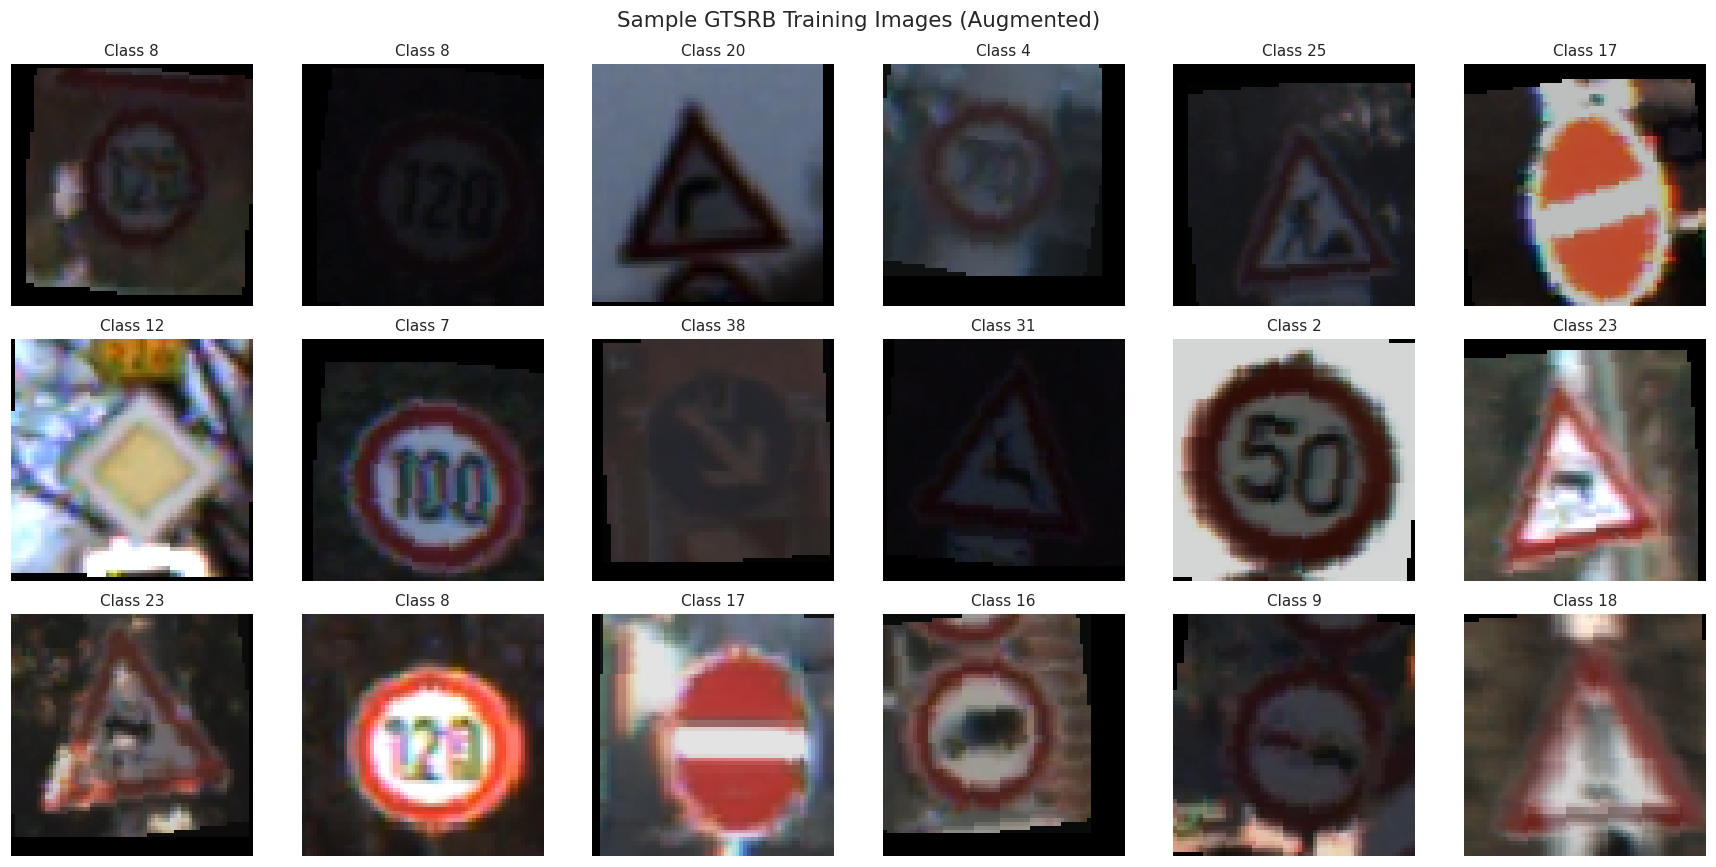

In [10]:
def denormalize(img_tensor, mean=cfg.MEAN, std=cfg.STD):
    img = img_tensor.clone().permute(1, 2, 0).numpy()
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
imgs, labels = next(iter(train_loader))

for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(imgs[i]))
    ax.set_title(f"Class {labels[i].item()}", fontsize=10)
    ax.axis("off")

plt.suptitle("Sample GTSRB Training Images (Augmented)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{cfg.FIGURE_DIR}/sample_images.png", bbox_inches="tight")
plt.show()

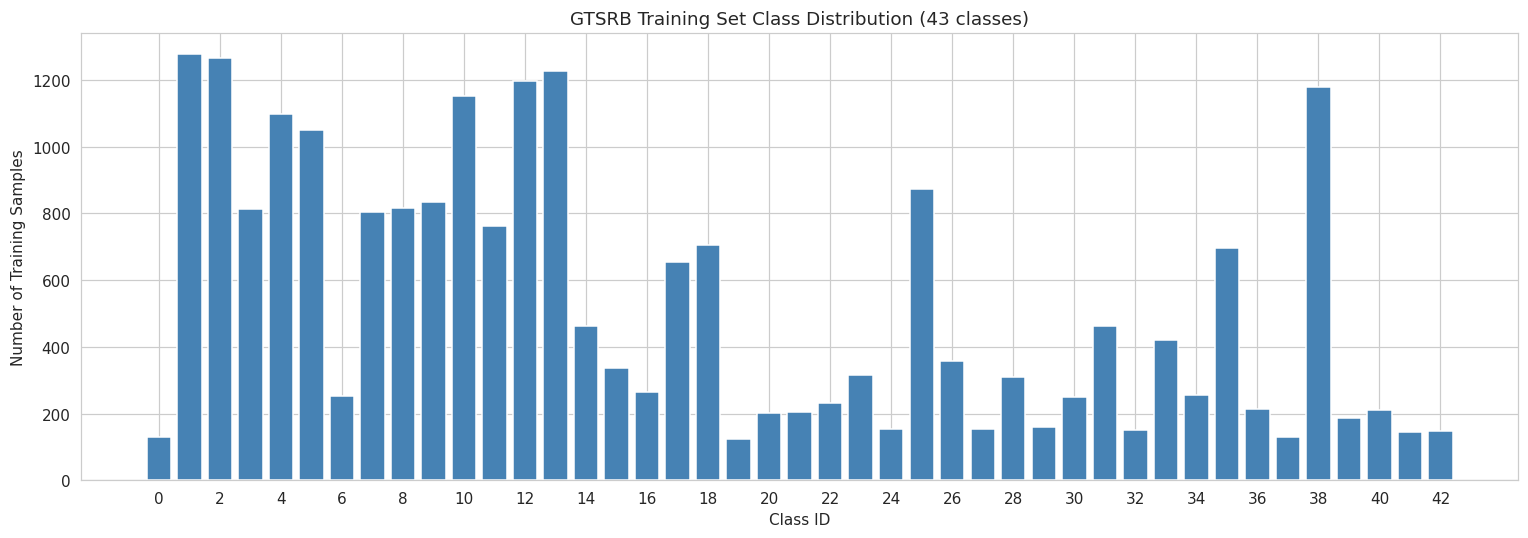

Min class count: 125
Max class count: 1277
Mean class count: 526.6
Note: GTSRB is imbalanced; this motivates monitoring per-class F1 in addition to accuracy.


In [11]:
train_labels = [gtsrb_train_pil._samples[i][1] for i in train_indices]
class_counts = Counter(train_labels)
counts_sorted = [class_counts.get(c, 0) for c in range(cfg.NUM_CLASSES)]

plt.figure(figsize=(14, 5))
plt.bar(range(cfg.NUM_CLASSES), counts_sorted, color="steelblue")
plt.xlabel("Class ID")
plt.ylabel("Number of Training Samples")
plt.title("GTSRB Training Set Class Distribution (43 classes)")
plt.xticks(range(0, cfg.NUM_CLASSES, 2))
plt.tight_layout()
plt.savefig(f"{cfg.FIGURE_DIR}/class_distribution.png", bbox_inches="tight")
plt.show()

print(f"Min class count: {min(counts_sorted)}")
print(f"Max class count: {max(counts_sorted)}")
print(f"Mean class count: {np.mean(counts_sorted):.1f}")
print("Note: GTSRB is imbalanced; this motivates monitoring per-class F1 in addition to accuracy.")

In [12]:
class BaselineCNN(nn.Module):
    """A compact CNN trained from scratch as the non-transfer-learning baseline."""
    def __init__(self, num_classes=cfg.NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64 -> 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32 -> 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16 -> 8

            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

baseline_cnn = BaselineCNN().to(device)
print(baseline_cnn)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 1

In [13]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_parameters(baseline_cnn)
print(f"BaselineCNN — Total params: {total:,} | Trainable: {trainable:,}")

summary(baseline_cnn, input_size=(1, 3, cfg.IMG_SIZE, cfg.IMG_SIZE))

BaselineCNN — Total params: 331,979 | Trainable: 331,979


Layer (type:depth-idx)                   Output Shape              Param #
BaselineCNN                              [1, 43]                   --
├─Sequential: 1-1                        [1, 128, 1, 1]            --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─BatchNorm2d: 2-2                  [1, 32, 64, 64]           64
│    └─ReLU: 2-3                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-4                       [1, 32, 64, 64]           9,248
│    └─BatchNorm2d: 2-5                  [1, 32, 64, 64]           64
│    └─ReLU: 2-6                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-7                    [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 64, 32, 32]           18,496
│    └─BatchNorm2d: 2-9                  [1, 64, 32, 32]           128
│    └─ReLU: 2-10                        [1, 64, 32, 32]           --
│    └─Conv2d: 2-11                      [1, 64, 32, 32]           36,928
│ 

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, running_correct, n_samples = 0.0, 0, 0

    pbar = tqdm(loader, desc="Training", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        n_samples += imgs.size(0)
        pbar.set_postfix(loss=running_loss / n_samples, acc=running_correct / n_samples)

    return running_loss / n_samples, running_correct / n_samples


def train_model(model, train_loader, val_loader, epochs, lr, weight_decay,
                 model_name, device, patience=cfg.PATIENCE):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        elapsed = time.time() - t0
        print(f"[{model_name}] Epoch {epoch}/{epochs} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | {elapsed:.1f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

print("Training function defined.")

Training function defined.


In [15]:
@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss, running_correct, n_samples = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        n_samples += imgs.size(0)

    return running_loss / n_samples, running_correct / n_samples


@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

print("Evaluation functions defined.")

Evaluation functions defined.


In [16]:
set_seed(SEED)
baseline_cnn = BaselineCNN().to(device)

baseline_cnn, cnn_history = train_model(
    model=baseline_cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=cfg.EPOCHS_CNN,
    lr=cfg.LR_CNN,
    weight_decay=cfg.WEIGHT_DECAY,
    model_name="BaselineCNN",
    device=device,
)

torch.save(baseline_cnn.state_dict(), f"{cfg.CHECKPOINT_DIR}/baseline_cnn.pt")
print("BaselineCNN training complete. Checkpoint saved.")

Training:   0%|          | 0/176 [00:00<?, ?it/s]

[BaselineCNN] Epoch 1/15 | train_loss=2.8914 train_acc=0.1875 | val_loss=2.5098 val_acc=0.2700 | 15.0s


Training:   0%|          | 0/176 [00:00<?, ?it/s]

[BaselineCNN] Epoch 2/15 | train_loss=1.9643 train_acc=0.3798 | val_loss=1.7629 val_acc=0.4144 | 14.1s


Training:   0%|          | 0/176 [00:00<?, ?it/s]

...

Training:   0%|          | 0/176 [00:00<?, ?it/s]

[BaselineCNN] Epoch 14/15 | train_loss=0.0659 train_acc=0.9804 | val_loss=0.1569 val_acc=0.9487 | 14.8s


Training:   0%|          | 0/176 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4b23f8a200>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7e4b23f8a200>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^^    
self._shutdown_workers()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
assert self._parent_pid == os.getpid(), 'can only test a child process'    
if w.is_alive(): 
               ^ ^ ^^^^^^^^^^^^^^^^^^^^
^^

[BaselineCNN] Epoch 15/15 | train_loss=0.0711 train_acc=0.9794 | val_loss=0.0239 val_acc=0.9947 | 15.2s
BaselineCNN training complete. Checkpoint saved.


In [17]:
criterion = nn.CrossEntropyLoss()
cnn_test_loss, cnn_test_acc = evaluate_model(baseline_cnn, test_loader, criterion, device)
cnn_preds, cnn_labels = get_predictions(baseline_cnn, test_loader, device)
cnn_f1 = f1_score(cnn_labels, cnn_preds, average="macro")

print(f"BaselineCNN — Test Loss: {cnn_test_loss:.4f}")
print(f"BaselineCNN — Test Accuracy: {cnn_test_acc:.4f}")
print(f"BaselineCNN — Macro F1: {cnn_f1:.4f}")

BaselineCNN — Test Loss: 0.1601
BaselineCNN — Test Accuracy: 0.9643
BaselineCNN — Macro F1: 0.9572


In [18]:
def build_resnet18(num_classes=cfg.NUM_CLASSES, freeze_backbone=False):
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes),
    )
    return model

resnet18_model = build_resnet18(freeze_backbone=False).to(device)
total, trainable = count_parameters(resnet18_model)
print(f"ResNet18 — Total params: {total:,} | Trainable: {trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]

ResNet18 — Total params: 11,198,571 | Trainable: 11,198,571


In [19]:
set_seed(SEED)
resnet18_model = build_resnet18(freeze_backbone=False).to(device)

resnet18_model, resnet_history = train_model(
    model=resnet18_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=cfg.EPOCHS_RESNET,
    lr=cfg.LR_RESNET,
    weight_decay=cfg.WEIGHT_DECAY,
    model_name="ResNet18",
    device=device,
)

torch.save(resnet18_model.state_dict(), f"{cfg.CHECKPOINT_DIR}/resnet18.pt")
print("ResNet18 training complete. Checkpoint saved.")

Training:   0%|          | 0/176 [00:00<?, ?it/s]

[ResNet18] Epoch 1/10 | train_loss=1.3166 train_acc=0.6360 | val_loss=0.1871 val_acc=0.9555 | 14.3s


Training:   0%|          | 0/176 [00:00<?, ?it/s]

[ResNet18] Epoch 2/10 | train_loss=0.1539 train_acc=0.9562 | val_loss=0.0479 val_acc=0.9872 | 14.4s


Training:   0%|          | 0/176 [00:00<?, ?it/s]

...

Training:   0%|          | 0/176 [00:00<?, ?it/s]

Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4b23f8a200>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4b23f8a200>if w.is_alive():

Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
      self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
      if w.is_alive():^
^ ^ ^ ^ ^ ^ ^ ^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^ ^ 
   File "/usr/lib

[ResNet18] Epoch 9/10 | train_loss=0.0144 train_acc=0.9957 | val_loss=0.0079 val_acc=0.9975 | 15.4s


Training:   0%|          | 0/176 [00:00<?, ?it/s]

[ResNet18] Epoch 10/10 | train_loss=0.0150 train_acc=0.9959 | val_loss=0.0097 val_acc=0.9965 | 14.7s
ResNet18 training complete. Checkpoint saved.


In [20]:
resnet_test_loss, resnet_test_acc = evaluate_model(resnet18_model, test_loader, criterion, device)
resnet_preds, resnet_labels = get_predictions(resnet18_model, test_loader, device)
resnet_f1 = f1_score(resnet_labels, resnet_preds, average="macro")

print(f"ResNet18 — Test Loss: {resnet_test_loss:.4f}")
print(f"ResNet18 — Test Accuracy: {resnet_test_acc:.4f}")
print(f"ResNet18 — Macro F1: {resnet_f1:.4f}")

ResNet18 — Test Loss: 0.1486
ResNet18 — Test Accuracy: 0.9572
ResNet18 — Macro F1: 0.9285


In [21]:
def build_efficientnet_b0(num_classes=cfg.NUM_CLASSES, freeze_backbone=False):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model

efficientnet_model = build_efficientnet_b0(freeze_backbone=False).to(device)
total, trainable = count_parameters(efficientnet_model)
print(f"EfficientNet-B0 — Total params: {total:,} | Trainable: {trainable:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


EfficientNet-B0 — Total params: 4,062,631 | Trainable: 4,062,631


In [22]:
set_seed(SEED)
efficientnet_model = build_efficientnet_b0(freeze_backbone=False).to(device)

efficientnet_model, effnet_history = train_model(
    model=efficientnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=cfg.EPOCHS_EFFNET,
    lr=cfg.LR_EFFNET,
    weight_decay=cfg.WEIGHT_DECAY,
    model_name="EfficientNet-B0",
    device=device,
)

torch.save(efficientnet_model.state_dict(), f"{cfg.CHECKPOINT_DIR}/efficientnet_b0.pt")
print("EfficientNet-B0 training complete. Checkpoint saved.")

Training:   0%|          | 0/176 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 1/10 | train_loss=2.6845 train_acc=0.3176 | val_loss=1.5710 val_acc=0.5816 | 15.5s


Training:   0%|          | 0/176 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4b23f8a200>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4b23f8a200>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[EfficientNet-B0] Epoch 2/10 | train_loss=1.1802 train_acc=0.6551 | val_loss=0.6393 val_acc=0.8138 | 14.7s


...

Training:   0%|          | 0/176 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 9/10 | train_loss=0.0579 train_acc=0.9832 | val_loss=0.0172 val_acc=0.9942 | 14.5s


Training:   0%|          | 0/176 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4b23f8a200>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
      Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4b23f8a200> 
  Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ ^ ^ ^ ^ ^ ^^^^^^^^^^

[EfficientNet-B0] Epoch 10/10 | train_loss=0.0457 train_acc=0.9867 | val_loss=0.0133 val_acc=0.9960 | 14.6s
EfficientNet-B0 training complete. Checkpoint saved.


In [23]:
effnet_test_loss, effnet_test_acc = evaluate_model(efficientnet_model, test_loader, criterion, device)
effnet_preds, effnet_labels = get_predictions(efficientnet_model, test_loader, device)
effnet_f1 = f1_score(effnet_labels, effnet_preds, average="macro")

print(f"EfficientNet-B0 — Test Loss: {effnet_test_loss:.4f}")
print(f"EfficientNet-B0 — Test Accuracy: {effnet_test_acc:.4f}")
print(f"EfficientNet-B0 — Macro F1: {effnet_f1:.4f}")

EfficientNet-B0 — Test Loss: 0.2132
EfficientNet-B0 — Test Accuracy: 0.9383
EfficientNet-B0 — Macro F1: 0.8993


In [24]:
set_seed(SEED)
effnet_no_aug = build_efficientnet_b0(freeze_backbone=False).to(device)

effnet_no_aug, effnet_no_aug_history = train_model(
    model=effnet_no_aug,
    train_loader=train_loader_no_aug,   # no augmentation
    val_loader=val_loader,
    epochs=cfg.EPOCHS_EFFNET,
    lr=cfg.LR_EFFNET,
    weight_decay=cfg.WEIGHT_DECAY,
    model_name="EfficientNet-B0 (No Augmentation)",
    device=device,
)

no_aug_test_loss, no_aug_test_acc = evaluate_model(effnet_no_aug, test_loader, criterion, device)
no_aug_preds, no_aug_labels = get_predictions(effnet_no_aug, test_loader, device)
no_aug_f1 = f1_score(no_aug_labels, no_aug_preds, average="macro")

ablation_results = pd.DataFrame([
    {"Configuration": "With Augmentation", "Test Accuracy": effnet_test_acc, "Macro F1": effnet_f1},
    {"Configuration": "Without Augmentation", "Test Accuracy": no_aug_test_acc, "Macro F1": no_aug_f1},
])
print(ablation_results.to_string(index=False))
ablation_results.to_csv(f"{cfg.RESULTS_DIR}/ablation_study.csv", index=False)

Training:   0%|          | 0/176 [00:00<?, ?it/s]

[EfficientNet-B0 (No Augmentation)] Epoch 1/10 | train_loss=2.4555 train_acc=0.3963 | val_loss=1.1616 val_acc=0.7082 | 8.8s


Training:   0%|          | 0/176 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4b23f8a200>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
     Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4b23f8a200> 
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^ ^^ ^ ^ ^ ^ ^ 
 ^  File "/us

[EfficientNet-B0 (No Augmentation)] Epoch 2/10 | train_loss=0.7679 train_acc=0.7977 | val_loss=0.2933 val_acc=0.9309 | 8.8s


...

[EfficientNet-B0 (No Augmentation)] Epoch 8/10 | train_loss=0.0190 train_acc=0.9963 | val_loss=0.0189 val_acc=0.9942 | 8.6s


Training:   0%|          | 0/176 [00:00<?, ?it/s]

[EfficientNet-B0 (No Augmentation)] Epoch 9/10 | train_loss=0.0160 train_acc=0.9963 | val_loss=0.0139 val_acc=0.9960 | 8.6s


Training:   0%|          | 0/176 [00:00<?, ?it/s]

[EfficientNet-B0 (No Augmentation)] Epoch 10/10 | train_loss=0.0134 train_acc=0.9969 | val_loss=0.0101 val_acc=0.9967 | 8.6s
       Configuration  Test Accuracy  Macro F1
   With Augmentation       0.938321  0.899276
Without Augmentation       0.921932  0.871819


In [25]:
@torch.no_grad()
def benchmark_inference(model, device, img_size=cfg.IMG_SIZE, n_warmup=20, n_runs=200, batch_size=1):
    model.eval()
    dummy_input = torch.randn(batch_size, 3, img_size, img_size).to(device)

    # Warmup
    for _ in range(n_warmup):
        _ = model(dummy_input)
    if device.type == "cuda":
        torch.cuda.synchronize()

    timings = []
    for _ in range(n_runs):
        start = time.perf_counter()
        _ = model(dummy_input)
        if device.type == "cuda":
            torch.cuda.synchronize()
        timings.append(time.perf_counter() - start)

    timings = np.array(timings) * 1000  # ms
    return {
        "mean_ms": timings.mean(),
        "std_ms": timings.std(),
        "p95_ms": np.percentile(timings, 95),
        "fps": 1000.0 / timings.mean(),
    }

models_to_benchmark = {
    "BaselineCNN": baseline_cnn,
    "ResNet18": resnet18_model,
    "EfficientNet-B0": efficientnet_model,
}

benchmark_results = []
for name, m in models_to_benchmark.items():
    stats = benchmark_inference(m, device)
    stats["Model"] = name
    benchmark_results.append(stats)
    print(f"{name}: {stats['mean_ms']:.2f} ms/img (±{stats['std_ms']:.2f}), "
          f"{stats['fps']:.1f} FPS, p95={stats['p95_ms']:.2f} ms")

benchmark_df = pd.DataFrame(benchmark_results)[["Model", "mean_ms", "std_ms", "p95_ms", "fps"]]
benchmark_df.to_csv(f"{cfg.RESULTS_DIR}/inference_benchmark.csv", index=False)

BaselineCNN: 1.11 ms/img (±0.02), 899.4 FPS, p95=1.16 ms
ResNet18: 2.76 ms/img (±0.09), 361.8 FPS, p95=2.83 ms
EfficientNet-B0: 8.73 ms/img (±0.32), 114.5 FPS, p95=9.02 ms


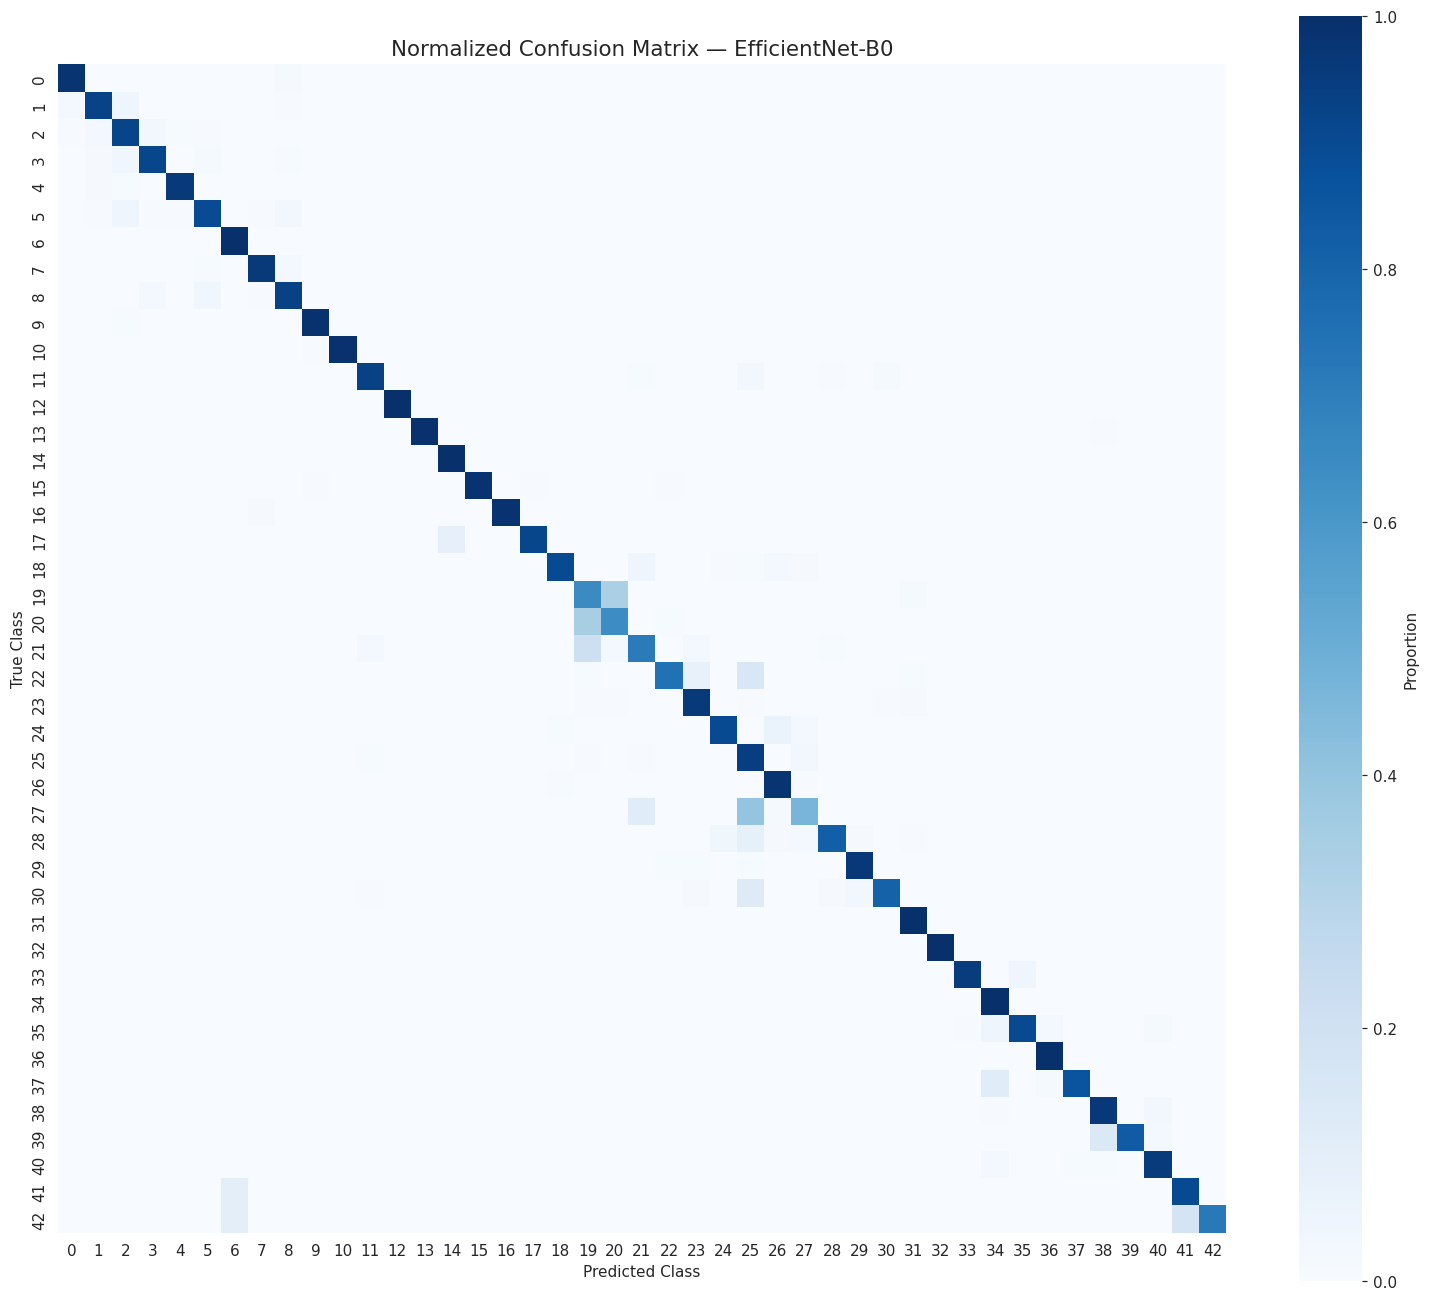

In [26]:
def plot_confusion_matrix(preds, labels, model_name, num_classes=cfg.NUM_CLASSES, save_path=None):
    cm = confusion_matrix(labels, preds, labels=list(range(num_classes)))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

    plt.figure(figsize=(14, 12))
    sns.heatmap(cm_norm, cmap="Blues", square=True, cbar_kws={"label": "Proportion"})
    plt.title(f"Normalized Confusion Matrix — {model_name}", fontsize=14)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    return cm

# Best model (EfficientNet-B0) confusion matrix
effnet_cm = plot_confusion_matrix(
    effnet_preds, effnet_labels, "EfficientNet-B0",
    save_path=f"{cfg.FIGURE_DIR}/confusion_matrix_efficientnet.png",
)

In [27]:
class_names = [str(i) for i in range(cfg.NUM_CLASSES)]

report_dict = classification_report(
    effnet_labels, effnet_preds, target_names=class_names,
    output_dict=True, zero_division=0,
)
report_df = pd.DataFrame(report_dict).transpose()
print(classification_report(effnet_labels, effnet_preds, target_names=class_names, zero_division=0))

report_df.to_csv(f"{cfg.RESULTS_DIR}/classification_report_efficientnet.csv")
print("Classification report saved.")

              precision    recall  f1-score   support

           0       0.75      0.98      0.85        60
           1       0.95      0.93      0.94       720
           2       0.89      0.93      0.90       750
           3       0.91      0.92      0.91       450
           4       0.98      0.96      0.97       660
           5       0.94      0.90      0.92       630
           6       0.91      1.00      0.95       150
           7       0.98      0.96      0.97       450
           8       0.90      0.93      0.92       450
           9       0.99      0.99      0.99       480
          10       1.00      0.99      1.00       660
          11       0.98      0.93      0.96       420
          12       1.00      1.00      1.00       690
          13       1.00      1.00      1.00       720
          14       0.90      1.00      0.95       270
          15       1.00      0.99      0.99       210
          16       0.99      0.99      0.99       150
          17       1.00    

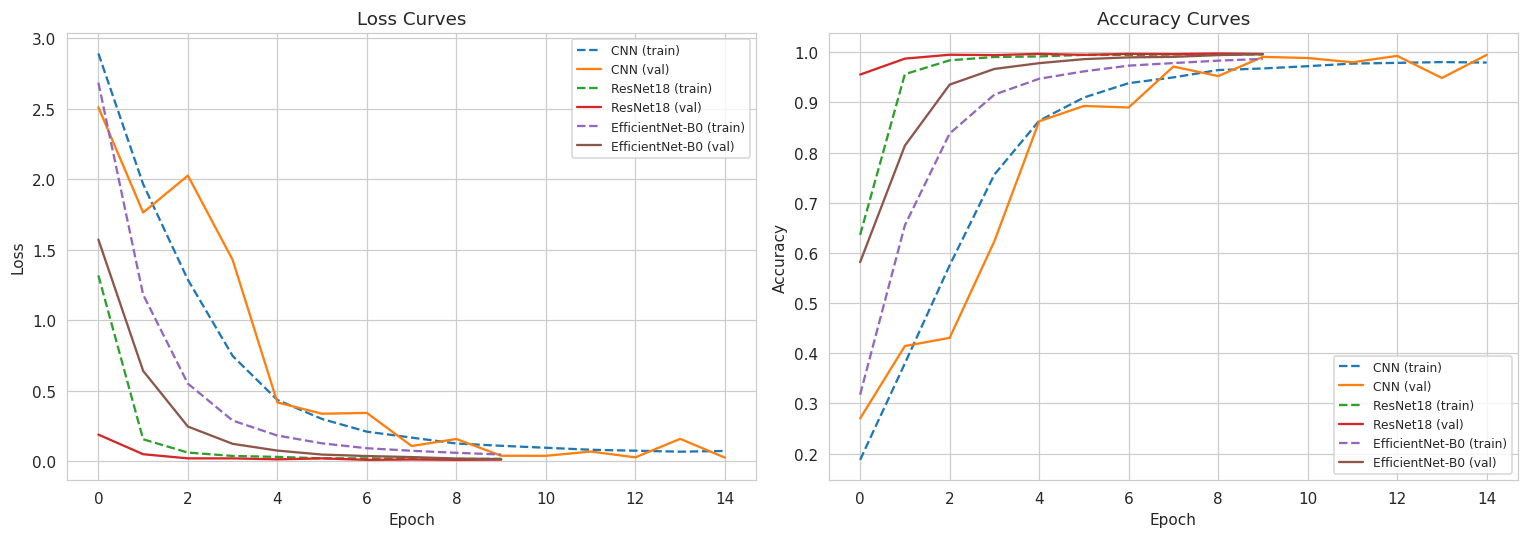

In [28]:
def plot_learning_curves(histories, model_names, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for hist, name in zip(histories, model_names):
        axes[0].plot(hist["train_loss"], label=f"{name} (train)", linestyle="--")
        axes[0].plot(hist["val_loss"], label=f"{name} (val)")
        axes[1].plot(hist["train_acc"], label=f"{name} (train)", linestyle="--")
        axes[1].plot(hist["val_acc"], label=f"{name} (val)")

    axes[0].set_title("Loss Curves")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend(fontsize=8)

    axes[1].set_title("Accuracy Curves")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_learning_curves(
    [cnn_history, resnet_history, effnet_history],
    ["CNN", "ResNet18", "EfficientNet-B0"],
    save_path=f"{cfg.FIGURE_DIR}/learning_curves.png",
)

In [29]:
comparison_df = pd.DataFrame([
    {
        "Model": "CNN (from scratch)",
        "Test Accuracy": cnn_test_acc,
        "Macro F1": cnn_f1,
        "Params (M)": count_parameters(baseline_cnn)[0] / 1e6,
        "Inference (ms)": benchmark_df.loc[benchmark_df.Model == "BaselineCNN", "mean_ms"].values[0],
        "FPS": benchmark_df.loc[benchmark_df.Model == "BaselineCNN", "fps"].values[0],
    },
    {
        "Model": "ResNet18 (transfer)",
        "Test Accuracy": resnet_test_acc,
        "Macro F1": resnet_f1,
        "Params (M)": count_parameters(resnet18_model)[0] / 1e6,
        "Inference (ms)": benchmark_df.loc[benchmark_df.Model == "ResNet18", "mean_ms"].values[0],
        "FPS": benchmark_df.loc[benchmark_df.Model == "ResNet18", "fps"].values[0],
    },
    {
        "Model": "EfficientNet-B0 (transfer)",
        "Test Accuracy": effnet_test_acc,
        "Macro F1": effnet_f1,
        "Params (M)": count_parameters(efficientnet_model)[0] / 1e6,
        "Inference (ms)": benchmark_df.loc[benchmark_df.Model == "EfficientNet-B0", "mean_ms"].values[0],
        "FPS": benchmark_df.loc[benchmark_df.Model == "EfficientNet-B0", "fps"].values[0],
    },
])

comparison_df = comparison_df.round(4)
print(comparison_df.to_string(index=False))
comparison_df.to_csv(f"{cfg.RESULTS_DIR}/model_comparison.csv", index=False)

                     Model  Test Accuracy  Macro F1  Params (M)  Inference (ms)      FPS
        CNN (from scratch)         0.9643    0.9572      0.3320          1.1118 899.4079
       ResNet18 (transfer)         0.9572    0.9285     11.1986          2.7638 361.8236
EfficientNet-B0 (transfer)         0.9383    0.8993      4.0626          8.7329 114.5100


In [30]:
checkpoint_paths = {
    "BaselineCNN": f"{cfg.CHECKPOINT_DIR}/baseline_cnn.pt",
    "ResNet18": f"{cfg.CHECKPOINT_DIR}/resnet18.pt",
    "EfficientNet-B0": f"{cfg.CHECKPOINT_DIR}/efficientnet_b0.pt",
    "EfficientNet-B0-NoAug": f"{cfg.CHECKPOINT_DIR}/efficientnet_b0_no_aug.pt",
}

torch.save(effnet_no_aug.state_dict(), checkpoint_paths["EfficientNet-B0-NoAug"])

for name, path in checkpoint_paths.items():
    size_mb = os.path.getsize(path) / 1e6 if os.path.exists(path) else 0
    print(f"{name}: {path} ({size_mb:.2f} MB)")

print("All checkpoints confirmed saved.")

BaselineCNN: ./checkpoints/baseline_cnn.pt (1.35 MB)
ResNet18: ./checkpoints/resnet18.pt (44.87 MB)
EfficientNet-B0: ./checkpoints/efficientnet_b0.pt (16.55 MB)
EfficientNet-B0-NoAug: ./checkpoints/efficientnet_b0_no_aug.pt (16.55 MB)
All checkpoints confirmed saved.


In [31]:
saved_figures = sorted(os.listdir(cfg.FIGURE_DIR))
print(f"Figures saved in '{cfg.FIGURE_DIR}':")
for f in saved_figures:
    print(f"  - {f}")

Figures saved in './figures':
  - class_distribution.png
  - confusion_matrix_efficientnet.png
  - learning_curves.png
  - sample_images.png


In [32]:
all_results = {
    "config": {k: v for k, v in vars(Config).items() if not k.startswith("__")},
    "cnn": {"test_acc": cnn_test_acc, "test_loss": cnn_test_loss, "macro_f1": cnn_f1},
    "resnet18": {"test_acc": resnet_test_acc, "test_loss": resnet_test_loss, "macro_f1": resnet_f1},
    "efficientnet_b0": {"test_acc": effnet_test_acc, "test_loss": effnet_test_loss, "macro_f1": effnet_f1},
    "ablation": {
        "with_aug_acc": effnet_test_acc,
        "without_aug_acc": no_aug_test_acc,
    },
    "inference_benchmark": benchmark_df.to_dict(orient="records"),
    "histories": {
        "cnn": cnn_history,
        "resnet18": resnet_history,
        "efficientnet_b0": effnet_history,
        "efficientnet_b0_no_aug": effnet_no_aug_history,
    },
}

with open(f"{cfg.RESULTS_DIR}/all_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print(f"Full results exported to {cfg.RESULTS_DIR}/all_results.json")

Full results exported to ./results/all_results.json


In [33]:
print("=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)
print(comparison_df.to_string(index=False))
print("-" * 60)
best_row = comparison_df.loc[comparison_df["Test Accuracy"].idxmax()]
print(f"Best model by accuracy: {best_row['Model']} ({best_row['Test Accuracy']:.4f})")
print("-" * 60)
print(f"Augmentation impact on EfficientNet-B0: "
      f"{effnet_test_acc - no_aug_test_acc:+.4f} accuracy delta")
print("=" * 60)
print("All checkpoints, figures, and results have been saved to:")
print(f"  Checkpoints: {cfg.CHECKPOINT_DIR}")
print(f"  Figures:     {cfg.FIGURE_DIR}")
print(f"  Results:     {cfg.RESULTS_DIR}")
print("=" * 60)

FINAL PROJECT SUMMARY
                     Model  Test Accuracy  Macro F1  Params (M)  Inference (ms)      FPS
        CNN (from scratch)         0.9643    0.9572      0.3320          1.1118 899.4079
       ResNet18 (transfer)         0.9572    0.9285     11.1986          2.7638 361.8236
EfficientNet-B0 (transfer)         0.9383    0.8993      4.0626          8.7329 114.5100
------------------------------------------------------------
Best model by accuracy: CNN (from scratch) (0.9643)
------------------------------------------------------------
Augmentation impact on EfficientNet-B0: +0.0164 accuracy delta
All checkpoints, figures, and results have been saved to:
  Checkpoints: ./checkpoints
  Figures:     ./figures
  Results:     ./results
